<a href="https://colab.research.google.com/github/xiaofei-builds/self-driving-rover/blob/main/notebooks/train_pilotnet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
!nvidia-smi

Thu Jul 30 05:31:02 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P0             28W /   70W |    2179MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [18]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


import os
ZIP = "/content/drive/MyDrive/xiaofei-builds/dataset.zip"
print("zip found:", os.path.exists(ZIP))

!unzip -q "{ZIP}" -d /content/dataset
print("contents:", os.listdir("/content/dataset"))
print("image count:", len(os.listdir("/content/dataset/data")))

In [19]:
import os
ZIP = "/content/drive/MyDrive/xiaofei-builds/dataset.zip"
print("zip found:", os.path.exists(ZIP))

!unzip -q "{ZIP}" -d /content/dataset
print("contents:", os.listdir("/content/dataset"))
print("image count:", len(os.listdir("/content/dataset/data")))

zip found: True
replace /content/dataset/data/img_002562.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
contents: ['data', 'labels.csv']
image count: 7780


(7780, 5)
   index                   timestamp           image  steering  throttle
0      0  2026-07-26T21:16:43.606880  img_000000.jpg         0        10
1      1  2026-07-26T21:16:43.638335  img_000001.jpg         0        10
2      2  2026-07-26T21:16:43.705097  img_000002.jpg         0        10

steering: -30 to 30


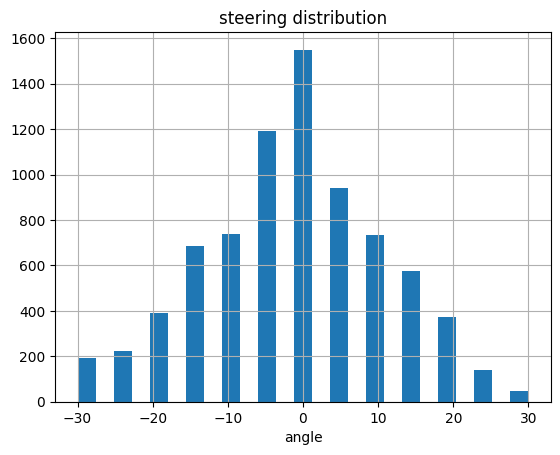

In [20]:
import pandas as pd, matplotlib.pyplot as plt
df = pd.read_csv("/content/dataset/labels.csv")
print(df.shape)
print(df.head(3))
print("\nsteering:", df.steering.min(), "to", df.steering.max())
df.steering.hist(bins=25); plt.title("steering distribution"); plt.xlabel("angle"); plt.show()

In [21]:
import numpy as np, cv2, os
from tqdm import tqdm
from sklearn.model_selection import train_test_split

IMG_DIR = "/content/dataset/data"
N = len(df)
X = np.zeros((N, 120, 160, 3), dtype=np.float32)
for i, fn in enumerate(tqdm(df.image.values)):
    img = cv2.imread(os.path.join(IMG_DIR, fn))   # BGR, 120x160
    X[i] = img[:, :, ::-1] / 255.0                # BGR->RGB, scale 0..1
y = (df.steering.values.astype(np.float32)) / 30.0  # scale -1..1

Xtr, Xval, ytr, yval = train_test_split(X, y, test_size=0.2, random_state=42)
print("train:", Xtr.shape, "  val:", Xval.shape)
print("pixel range:", X.min(), "to", X.max(), " | steering range:", y.min(), "to", y.max())

100%|██████████| 7780/7780 [00:06<00:00, 1132.41it/s]


train: (6224, 120, 160, 3)   val: (1556, 120, 160, 3)
pixel range: 0.0 to 0.7647059  | steering range: -1.0 to 1.0


In [22]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(120, 160, 3)),
    layers.Conv2D(24, 5, strides=2, activation='relu'),
    layers.Conv2D(32, 5, strides=2, activation='relu'),
    layers.Conv2D(64, 5, strides=2, activation='relu'),
    layers.Conv2D(64, 3, strides=2, activation='relu'),
    layers.Conv2D(64, 3, strides=1, activation='relu'),
    layers.Flatten(),
    layers.Dropout(0.2),
    layers.Dense(100, activation='relu'),
    layers.Dropout(0.1),
    layers.Dense(50, activation='relu'),
    layers.Dense(1)                      # linear output = steering
])
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='mse', metrics=['mae'])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 58, 78, 24)     │         1,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 27, 37, 32)     │        19,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 12, 17, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 5, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 3, 6, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │       115,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,577 (1.02 MB)

 Trainable params: 266,577 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

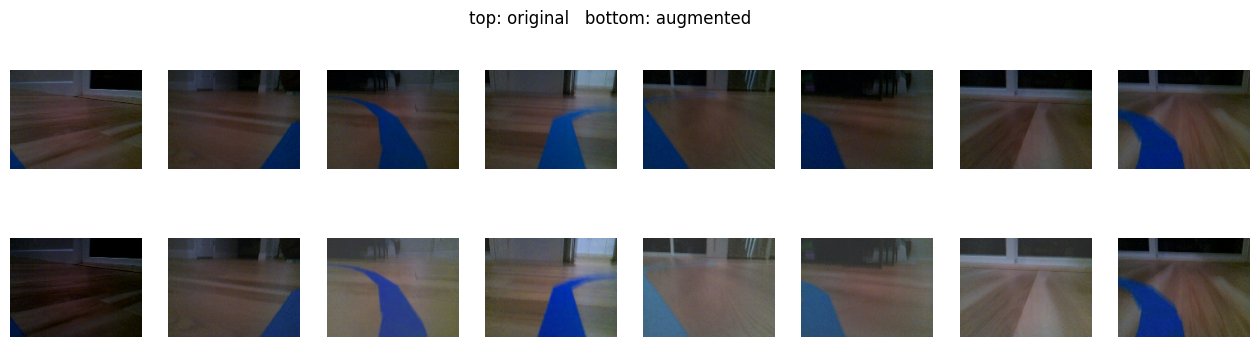

In [23]:
import tensorflow as tf, matplotlib.pyplot as plt
def augment(img, label):
    img = tf.image.random_brightness(img, 0.2)      # exposure
    img = tf.image.random_contrast(img, 0.8, 1.2)   # contrast
    img = tf.image.random_saturation(img, 0.7, 1.3) # color intensity
    img = tf.image.random_hue(img, 0.03)            # color temperature
    return tf.clip_by_value(img, 0.0, 1.0), label

s = Xtr[:8]
fig, ax = plt.subplots(2, 8, figsize=(16, 4))
for i in range(8):
    ax[0,i].imshow(s[i]); ax[0,i].axis('off')
    ax[1,i].imshow(augment(tf.constant(s[i]), 0.0)[0]); ax[1,i].axis('off')
plt.suptitle('top: original   bottom: augmented'); plt.show()

In [24]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = (tf.data.Dataset.from_tensor_slices((Xtr, ytr))
            .shuffle(len(Xtr)).map(augment, num_parallel_calls=AUTOTUNE)
            .batch(64).prefetch(AUTOTUNE))
val_ds = (tf.data.Dataset.from_tensor_slices((Xval, yval))
          .batch(64).prefetch(AUTOTUNE))          # NOT augmented

es = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=8,
                                      restore_best_weights=True)
history = model.fit(train_ds, validation_data=val_ds, epochs=60, callbacks=[es])

Epoch 1/60
98/98 ━━━━━━━━━━━━━━━━━━━━ 15s 84ms/step - loss: 0.1329 - mae: 0.2666 - val_loss: 0.1179 - val_mae: 0.2400
Epoch 2/60
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - loss: 0.0954 - mae: 0.2158 - val_loss: 0.0941 - val_mae: 0.2153
Epoch 3/60
98/98 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - loss: 0.0782 - mae: 0.1940 - val_loss: 0.0859 - val_mae: 0.1903
Epoch 4/60
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - loss: 0.0681 - mae: 0.1789 - val_loss: 0.0740 - val_mae: 0.1860
Epoch 5/60
98/98 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - loss: 0.0633 - mae: 0.1739 - val_loss: 0.0629 - val_mae: 0.1658
Epoch 6/60
98/98 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - loss: 0.0556 - mae: 0.1630 - val_loss: 0.0570 - val_mae: 0.1623
Epoch 7/60
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - loss: 0.0488 - mae: 0.1532 - val_loss: 0.0521 - val_mae: 0.1533
Epoch 8/60
98/98 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step - loss: 0.0466 - mae: 0.1502 - val_loss: 0.0472 - val_mae: 0.1511
Epoch 9/60
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - loss: 0.04

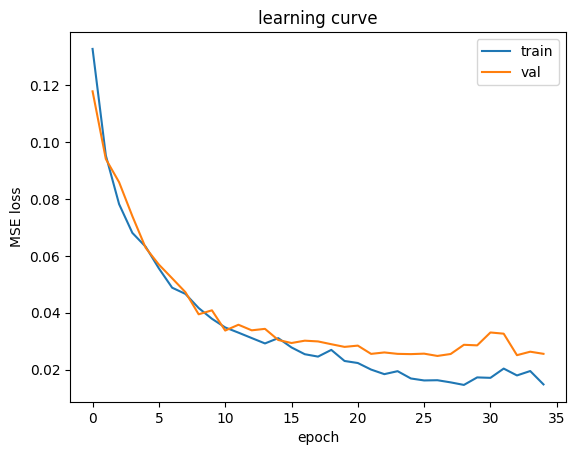

best val MAE (normalized): 0.1129
average steering error in DEGREES: 3.39


In [25]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend(); plt.xlabel('epoch'); plt.ylabel('MSE loss'); plt.title('learning curve'); plt.show()

best = min(history.history['val_mae'])
print("best val MAE (normalized):", round(best, 4))
print("average steering error in DEGREES:", round(best * 30, 2))


In [30]:
import numpy as np
idx = np.random.choice(len(Xval), 10, replace=False)
pred = (model.predict(Xval[idx], verbose=0) * 30).flatten()
true = yval[idx] * 30
print(" predicted | you drove")
for p, t in zip(pred, true):
    print(f"   {p:+6.1f}  |  {t:+6.1f}")

 predicted | you drove
     -4.0  |    +0.0
    +16.1  |   +15.0
     +8.2  |    +5.0
     -0.0  |    +0.0
     +6.7  |   +10.0
     -0.4  |   -10.0
    +13.8  |   +15.0
    -18.3  |   -15.0
    -10.3  |    -5.0
     +2.9  |    +0.0


In [27]:
import numpy as np

converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open("/content/pilot.tflite", "wb") as f:
    f.write(tflite_model)
print("TF-Lite size:", round(len(tflite_model)/1024, 1), "KB")

Saved artifact at '/tmp/tmpl6x_l86o'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 120, 160, 3), dtype=tf.float32, name='keras_tensor_24')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  139671802701072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139671802701648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139671802702608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139671802701840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139671802702992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139671802702800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139671802703376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139671802703184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139671802703760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139671802703568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13967180270

In [28]:
interp = tf.lite.Interpreter(model_content=tflite_model)
interp.allocate_tensors()
inp = interp.get_input_details()[0]
out = interp.get_output_details()[0]

x = Xval[0:1].astype(np.float32)
interp.set_tensor(inp['index'], x); interp.invoke()
tflite_pred = interp.get_tensor(out['index'])[0,0] * 30
keras_pred  = model.predict(x, verbose=0)[0,0] * 30
print(f"tflite: {tflite_pred:+.2f}   keras: {keras_pred:+.2f}")
print("input the Pi must feed:", inp['shape'], inp['dtype'])

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


tflite: -5.07   keras: -5.07
input the Pi must feed: [  1 120 160   3] <class 'numpy.float32'>


In [29]:
import shutil, os
DST = "/content/drive/MyDrive/xiaofei-builds/model"
os.makedirs(DST, exist_ok=True)
shutil.copy("/content/pilot.tflite", f"{DST}/pilot.tflite")   # for the Pi
model.save(f"{DST}/pilot.keras")                              # full backup for retraining
print(os.listdir(DST))

['pilot.tflite', 'pilot.keras']
